In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

# URL avec les spécifications (exemple)
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?where=equip_type_name%20like%20%27Court%20de%20tennis%27&limit=100"

In [ ]:
# A function that transforms a call of the api into a usable panda file 
def call_api(api_url):
    req = requests.get(api_url)
    wb = req.json()
    print(wb.keys())

    df = pd.DataFrame(wb['results'])
    return(df)

#Cette fonction mange directement le lien que sort l''interface de l'api donc pas besoin de le modifier, elle rend un panda directement
#Il sert à obtenir des tableaux plus grands sans la limite de 100
def call_csv(url):

    url = url.replace("records", "exports/csv")
    # Send a GET request to the URL
    response = requests.get(url)

# Ensure the request was successful (status code 200)
    if response.status_code == 200:
    # Save the content to a file
        with open('equipements_ile_de_france.csv', 'wb') as f:
            f.write(response.content)

    # Load the CSV into a pandas DataFrame
        df = pd.read_csv('equipements_ile_de_france.csv', delimiter=';')

    # Display the first few rows of the DataFrame
    else:
        print(f"Failed to retrieve CSV. Status code: {response.status_code}")
    return(df)

In [ ]:
#Un lien pour obtenir le nombre d'infrastructures par département
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=COUNT(inst_numero)&group_by=dep_nom&order_by=dep_code&limit=100"
tab = call_api(api_url)
tab

dict_keys(['results'])
                  dep_nom  COUNT(inst_numero)
0                    None                   3
1                     Ain                4118
2                   Aisne                3691
3                  Allier                2591
4         Alpes-Maritimes                3672
..                    ...                 ...
95                   Tarn                2821
96        Tarn-et-Garonne                1694
97  Territoire de Belfort                 865
98             Val-d'Oise                4014
99           Val-de-Marne                2915

[100 rows x 2 columns]


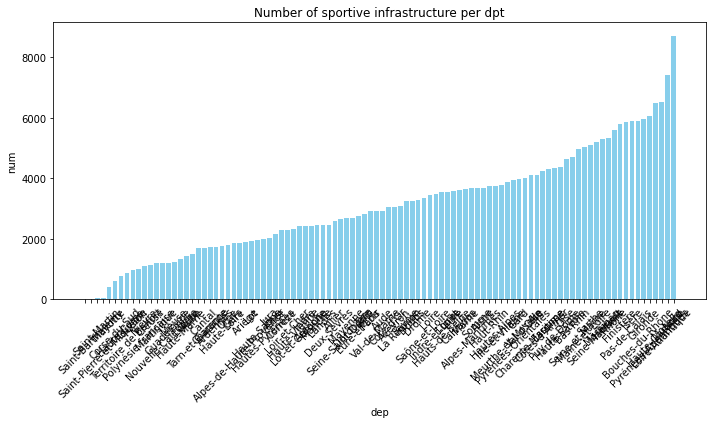

In [70]:
import numpy as np

#tab is the data from the previous call of the api (number of infrastructues per dpt)
tab = tab.sort_values(by='COUNT(inst_numero)', ascending=True)

y= tab['dep_nom']  # Sample data.

#fillna is to set NaN value to 0 so that plt.bar understands it
x = tab['COUNT(inst_numero)'].fillna(0)

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
plt.figure(figsize=(10, 6))

# Using range(len(x)) to plot bars for each department name
plt.bar(range(len(x)), x, color='skyblue')

# Labeling x-ticks with the department names
plt.xticks(range(len(x)), y, rotation=45)


plt.xlabel('dep')
plt.ylabel('num')
plt.title('Number of sportive infrastructure per dpt')

plt.tight_layout()       # Adjust layout for better appearance
plt.show()

In [71]:
# récupérer les superficies par département, sans les sites les plus grands (sites naturels et aménagés)

api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=dep_nom%2C%20equip_larg%2C%20equip_long%2C%20AVG(equip_larg*equip_long)%20as%20average_area&where=equip_larg%20is%20not%20null&group_by=dep_nom&order_by=dep_nom&limit=100"
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=dep_nom%2C%20dep_code%2C%20AVG(equip_larg*equip_long)%20as%20average_area&where=equip_nature%20!%3D%20%22Site%20naturel%22%20AND%20equip_nature%20!%3D%20%22Site%20naturel%20am%C3%A9nag%C3%A9%22%20AND%20dep_code%20!%3D%20%2222%22&group_by=dep_nom%2C%20dep_code&limit=100""#61-Verbes de déplacement.mp3"
tab = call_api(api_url)
tab

dict_keys(['results'])


,dep_nom,dep_code,average_area
0,Ain,1,3651.728920
1,Aisne,2,9823.213794
2,Allier,3,2733.722505
3,Alpes-Maritimes,6,2316.528559
4,Alpes-de-Haute-Provence,4,4916.349885
...,...,...,...
95,Territoire de Belfort,90,1245.022136
96,Val-d'Oise,95,3570.391274
97,Val-de-Marne,94,1321.744778
98,Var,83,379322.677413


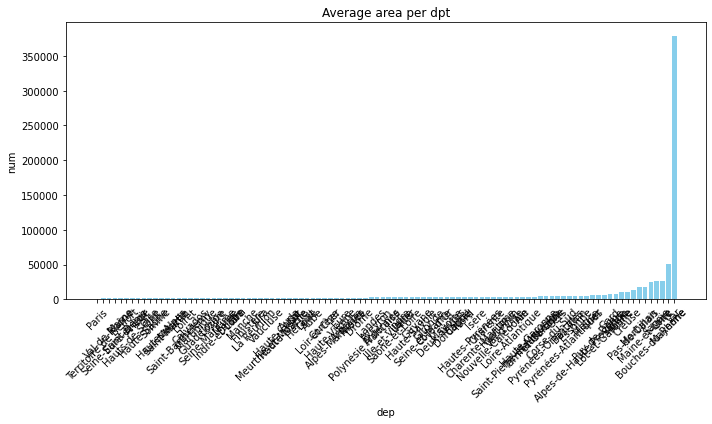

In [ ]:
# Aire moyenne des infrastructures 

# tab = tab.sort_values(by='average_area', ascending=True)

y= tab['dep_nom']  # Sample data.

#fillna is to set NaN value to 0 so that plt.bar understands it
x = tab['average_area'].fillna(0)

# Note that even in the OO-style, we use `.pyplot.figure` to create the Figure.
plt.figure(figsize=(10, 6))

# Using range(len(x)) to plot bars for each department name
plt.bar(range(len(x)), x, color='skyblue')

# Labeling x-ticks with the department names
plt.xticks(range(len(x)), y, rotation=45)


plt.xlabel('dep')
plt.ylabel('num')
plt.title('Average area per dpt')

plt.tight_layout()       # Adjust layout for better appearance
plt.show()

In [113]:
#Exemple de récupération de données à partir d'une url de l'api, à noter que la spécification limit = -1 est très importante dans la fin du lien
api_url = "https://equipements.sports.gouv.fr/api/explore/v2.1/catalog/datasets/data-es/records?select=COUNT(inst_numero)&group_by=dep_code_filled&order_by=dep_code&limit=-1"
gym_data = call_csv(api_url)
#gym_data


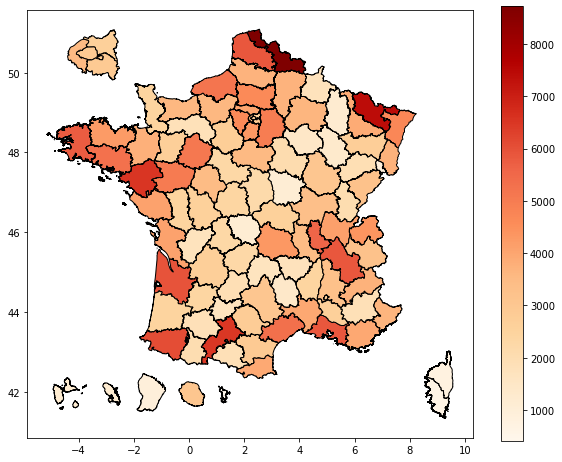

In [ ]:
import geopandas as gpd
from cartiflette import carti_download

departements = carti_download(
    values="France",
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

#pour accorder les deux colonnes sur lesquelles merge les bases de donnée, la synthèse se fait sur 'dep_code_filled'
# Le filled est très important, il faudra donc ne pas omettre cette variable dans la requête API

departements['INSEE_DEP'] = departements['INSEE_DEP'].astype(str)
gym_data['dep_code_filled'] = gym_data['dep_code_filled'].astype(str)

#To correct duplicated departments in cartiflette, aggregation along the department code
departements = departements.dissolve(by='INSEE_DEP')
departements = departements.reset_index()
departements['INSEE_DEP'] = departements['INSEE_DEP'].astype(str)

#To merge cartiflette data and the database imported
departements = departements.merge(gym_data, left_on="INSEE_DEP", right_on="dep_code_filled", how="left")

ax = departements.plot(
    column='COUNT(inst_numero)',            # La colonne utilisée pour colorier la carte
    cmap='OrRd',                  # Palette de couleurs (Orange-Red)
    legend=True,                  # Afficher une légende
    figsize=(10, 8),              # Taille de la carte
    edgecolor='black'             # Couleur des bordures
)


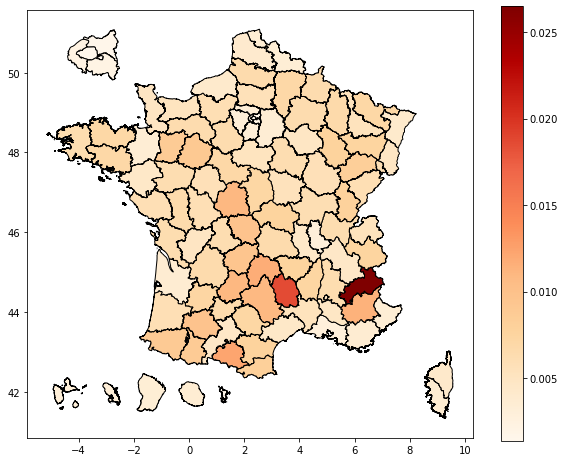

In [116]:
# Pour tracer un indice quelconque calculé à partir des valeurs de la grande matrice précédente ('departements'"Premier jet(1)(1).ipynb"
# Il suffit de changer le calcul dans la ligne suivante

departements['param_interet'] = departements['COUNT(inst_numero)']/departements['POPULATION']

ax = departements.plot(
    column='param_interet',            # La colonne utilisée pour colorier la carte
    cmap='OrRd',                  # Palette de couleurs (Orange-Red)
    legend=True,                  # Afficher une légende
    figsize=(10, 8),              # Taille de la carte
    edgecolor='black'             # Couleur des bordures
)

In [117]:
print(departements.head())

  INSEE_DEP                                           geometry    PAYS  \
0        01  POLYGON ((5.31063 46.44694, 5.30967 46.44662, ...  France   
1        02  POLYGON ((4.04823 49.40563, 4.05027 49.41226, ...  France   
2        03  POLYGON ((2.28109 46.42047, 2.28091 46.42022, ...  France   
3        04  POLYGON ((6.94842 44.6548, 6.94768 44.65489, 6...  France   
4        05  POLYGON ((6.94842 44.6548, 6.94874 44.65525, 6...  France   

       LIBELLE_DEPARTEMENT  POPULATION                            SOURCE  \
0                      Ain      652432  IGN:EXPRESS-COG-CARTO-TERRITOIRE   
1                    Aisne      531345  IGN:EXPRESS-COG-CARTO-TERRITOIRE   
2                   Allier      335975  IGN:EXPRESS-COG-CARTO-TERRITOIRE   
3  Alpes-de-Haute-Provence      164308  IGN:EXPRESS-COG-CARTO-TERRITOIRE   
4             Hautes-Alpes      141220  IGN:EXPRESS-COG-CARTO-TERRITOIRE   

  dep_code_filled  COUNT(inst_numero)     ratio  param_interet  
0              01                